# Using temporal CNN model to predict the weather

## About the model

In weather modeling, CNNs can:

Detect temporal patterns in past weather data (e.g., rainfall following humidity drops)

Learn relationships between multiple meteorological variables

Provide fast and accurate forecasts compared to traditional models

For example:

Input: 30 days of temperature, humidity, wind speed, rainfall

Output: predicted next day’s temperature or rainfall

Install all the necessary packages

In [13]:
%pip install tensorflow pandas scikit-learn matplotlib numpy

In [14]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [15]:
# Loading the dataset

df = pd.read_csv('cleaned_weather.csv')

In [16]:
# Sort by date
df = df.sort_values('date')

In [17]:
# A quick look at the data
df.head()

,location_id,weather_code (wmo code),temperature_2m_max (°C),temperature_2m_min (°C),temperature,apparent_temperature_max (°C),apparent_temperature_min (°C),apparent_temperature_mean (°C),daylight_duration (s),sunshine_duration (s),...,date,day_of_week,temperature_lag1,temperature_lag2,rainfall_lag1,rainfall_lag2,wind_speed_lag1,wind_speed_lag2,precipitation_lag1,precipitation_lag2
0,0,2,32.6,24.1,28.0,38.0,29.0,32.7,43161.09,40563.73,...,2010-01-03,6,26.4,26.0,15.7,0.0,11.6,12.2,15.7,0.0
22134,6,1,31.0,24.5,27.5,35.6,28.6,31.5,43215.11,40774.38,...,2010-01-03,6,26.2,26.1,10.0,0.4,10.9,7.2,10.0,0.4
88536,24,2,33.9,21.4,27.7,37.0,24.8,30.6,43138.55,39740.56,...,2010-01-03,6,25.2,24.1,0.1,0.0,14.1,17.7,0.1,0.0
29512,8,1,31.5,24.2,27.5,35.1,27.8,30.5,43210.61,40769.55,...,2010-01-03,6,26.1,26.0,0.6,0.0,17.8,18.2,0.6,0.0
70091,19,3,33.0,22.2,27.1,35.3,25.7,29.3,43070.81,40488.04,...,2010-01-03,6,25.6,24.7,0.0,0.0,15.8,19.0,0.0,0.0


In [18]:
# Select numeric columns only
numeric_cols = [
    'weather_code (wmo code)',
    'temperature_2m_max (°C)',
    'temperature_2m_min (°C)',
    'temperature',
    'apparent_temperature_max (°C)',
    'apparent_temperature_min (°C)',
    'apparent_temperature_mean (°C)',
    'daylight_duration (s)',
    'sunshine_duration (s)',
    'precipitation',
    'rainfall',
    'precipitation_hours (h)',
    'wind_speed',
    'wind_gusts_10m_max (km/h)',
    'wind_direction_10m_dominant (°)',
    'shortwave_radiation_sum (MJ/m²)',
    'et0_fao_evapotranspiration (mm)',
    'latitude',
    'longitude',
    'elevation',
    'year',
    'month',
    'day',
    'sunrise_hour',
    'sunset_hour',
    'daylight_hours',
    'temperature_lag1',
    'temperature_lag2',
    'rainfall_lag1',
    'rainfall_lag2',
    'wind_speed_lag1',
    'wind_speed_lag2',
    'precipitation_lag1',
    'precipitation_lag2'
]

In [19]:
# Drop all the empty rows
df = df.dropna(subset=numeric_cols)

In [20]:
# Scaling the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df[numeric_cols])

Below function is converting the dataset into 30-day weather data series pairing with the next day forecast
Because models like CNNs, LSTMs, or Transformers need fixed-length sequences as input, this function reshapes your time series into those sequences.

In [21]:
# For day time interval
def create_sequences(data, window=30):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])  # Predicting all variables next day
    return np.array(X), np.array(y)

In [22]:
# Creating the sequence
window_size = 30
X, y = create_sequences(data_scaled, window=window_size)

In [23]:
# Splitting test/train set
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [24]:
# --- Build Temporal CNN (TCN-like) ---
model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', padding='causal', input_shape=(window_size, len(numeric_cols))),
    Dropout(0.2),
    Conv1D(64, kernel_size=3, activation='relu', padding='causal'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(numeric_cols))   # predict all weather metrics
])

model.compile(optimizer=Adam(1e-3), loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 64)         │         6,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       245,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 34)             │         4,386 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,218 (1.03 MB)

 Trainable params: 269,218 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Training
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [26]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 0.6504 - val_loss: 0.6652
Epoch 2/100
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - loss: 0.5718 - val_loss: 0.6548
Epoch 3/100
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 0.5640 - val_loss: 0.6533
Epoch 4/100
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - loss: 0.5519 - val_loss: 0.6522
Epoch 5/100
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - loss: 0.5453 - val_loss: 0.6489
Epoch 6/100
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - loss: 0.5452 - val_loss: 0.6498
Epoch 7/100
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - loss: 0.5363 - val_loss: 0.6529
Epoch 8/100
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - loss: 0.5312 - val_loss: 0.6616
Epoch 9/100
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 29s 13ms/step - loss: 0.5322 - val_loss: 0.6489
Epoch 10/100
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - loss: 0.5238 - val_loss: 0.6482
Epoch 11/100
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - loss: 0.5236 - val_loss: 0.65

In [27]:
# Model evaluation
loss = model.evaluate(X_test, y_test)
print(f"Test Loss (MSE): {loss:.4f}")

623/623 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6567
Test Loss (MSE): 0.6879


623/623 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


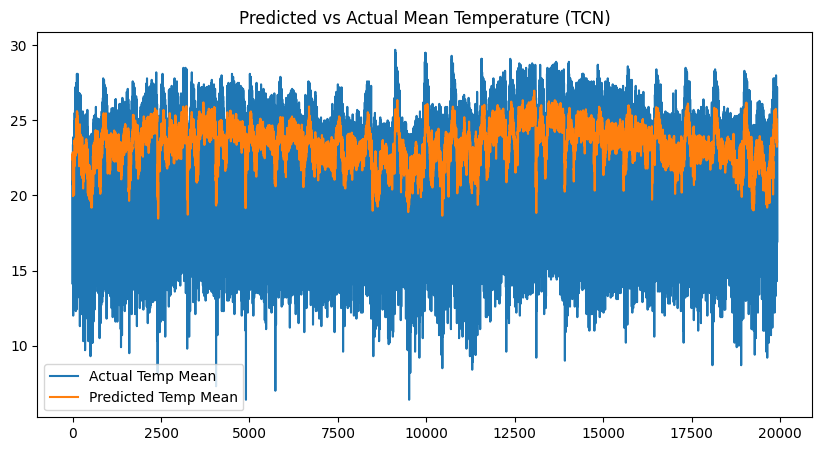

In [28]:
# Predict and visualize results
pred = model.predict(X_test)

# Inverse transform predictions for readability
pred_inv = scaler.inverse_transform(pred)
y_test_inv = scaler.inverse_transform(y_test)

plt.figure(figsize=(10,5))
plt.plot(y_test_inv[:, 2], label="Actual Temp Mean")  # column index 2 = temperature_2m_mean
plt.plot(pred_inv[:, 2], label="Predicted Temp Mean")
plt.legend()
plt.title("Predicted vs Actual Mean Temperature (TCN)")
plt.show()